# Customer Segmentation Analysis

**OIBSIP Data Analytics Internship — Task 2**

**Goal:** Group customers based on their purchasing behaviour using RFM analysis and K-Means clustering.

RFM means:
- **Recency:** How recently the customer purchased
- **Frequency:** How often the customer purchased
- **Monetary:** How much the customer spent

This is useful for identifying customer groups that can receive different marketing strategies.

## 1. Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## 2. Load the cleaned transaction data

In [2]:
df = pd.read_csv("data/retail_sales_transactions_cleaned.csv")

df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")

# Calculate sales value after discount
df["Sales_Value"] = df["Quantity"] * df["Unit_Price"] * (1 - df["Discount"] / 100)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (500, 13)


,Order_ID,Customer_Name,Gender,Category,Product,Quantity,Unit_Price,Discount,Order_Date,Sales_Channel,Region,Phone,Sales_Value
0,1000.0,Riya,Female,Clothing,Jacket,1.0,199.0,10.0,2024-01-25,Wholesale,Unknown,9876543210,179.10
1,1001.0,Sam,Female,Groceries,Rice,4.0,499.0,0.0,2024-10-26,Retail,Unknown,Unknown,1996.00
2,1002.0,Sam,Unknown,Electronics,Tablet,3.0,499.0,10.0,2024-01-02,Wholesale,South,9876543210,1347.30
3,1003.0,John,Male,Electronics,Mobile,3.0,499.0,5.0,2024-03-27,Retail,East,9876543210,1422.15
4,1004.0,John,Female,Clothing,Shirt,5.0,499.0,10.0,2024-08-30,Retail,West,Unknown,2245.50


## 3. Create RFM features

In [3]:
reference_date = df["Order_Date"].max() + pd.Timedelta(days=1)

rfm = df.groupby("Customer_Name").agg(
    Recency=("Order_Date", lambda x: (reference_date - x.max()).days),
    Frequency=("Order_ID", "count"),
    Monetary=("Sales_Value", "sum")
).reset_index()

print("Number of customers:", len(rfm))
rfm

Number of customers: 10


,Customer_Name,Recency,Frequency,Monetary
0,Ahmed,6,46,98698.70
1,Ali,2,46,81082.45
2,Asha,5,56,109219.65
3,Chen,2,53,92287.10
4,Emily,4,63,108870.05
5,John,1,59,121409.30
6,Maria,15,41,67761.70
7,Riya,33,39,67061.15
8,Sam,1,57,110672.75
9,Wei,1,40,79365.30


### Why RFM?

A customer who purchased recently, purchases often and spends more is usually more valuable than a customer who has not purchased for a long time and spends very little.

## 4. Check the RFM data

In [4]:
print(rfm[["Recency", "Frequency", "Monetary"]].describe())

         Recency  Frequency       Monetary
count  10.000000  10.000000      10.000000
mean    7.000000  50.000000   93642.815000
std    10.066446   8.679478   19151.240219
min     1.000000  39.000000   67061.150000
25%     1.250000  42.250000   79794.587500
50%     3.000000  49.500000   95492.900000
75%     5.750000  56.750000  109132.250000
max    33.000000  63.000000  121409.300000


## 5. Standardise RFM values

In [5]:
features = ["Recency", "Frequency", "Monetary"]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[features])

print("RFM values have been standardised.")

RFM values have been standardised.


## 6. Elbow Method

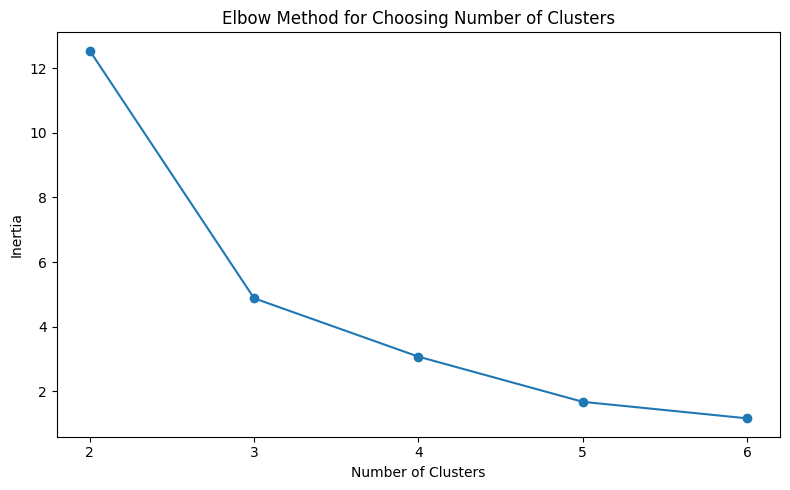

In [6]:
inertia = []

for k in range(2, 7):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(rfm_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 7), inertia, marker="o")
plt.title("Elbow Method for Choosing Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(range(2, 7))
plt.tight_layout()
plt.show()

### Observation

The elbow chart helps choose a cluster count where adding more clusters gives smaller improvements. For this small beginner dataset, 3 clusters provide an easy-to-interpret segmentation.

## 7. Apply K-Means clustering

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print(rfm.sort_values("Cluster").to_string(index=False))

Customer_Name  Recency  Frequency  Monetary  Cluster
        Ahmed        6         46  98698.70        0
          Ali        2         46  81082.45        0
         Chen        2         53  92287.10        0
          Wei        1         40  79365.30        0
        Maria       15         41  67761.70        1
         Riya       33         39  67061.15        1
         John        1         59 121409.30        2
         Asha        5         56 109219.65        2
        Emily        4         63 108870.05        2
          Sam        1         57 110672.75        2


## 8. Cluster profile

In [8]:
cluster_profile = rfm.groupby("Cluster")[features].mean().round(2)
cluster_size = rfm["Cluster"].value_counts().sort_index()

print("Average RFM values by cluster:")
print(cluster_profile)

print("\nCustomers in each cluster:")
print(cluster_size)

Average RFM values by cluster:
         Recency  Frequency   Monetary
Cluster                               
0           2.75      46.25   87858.39
1          24.00      40.00   67411.42
2           2.75      58.75  112542.94

Customers in each cluster:
Cluster
0    4
1    2
2    4
Name: count, dtype: int64


## 9. Visualise customer clusters

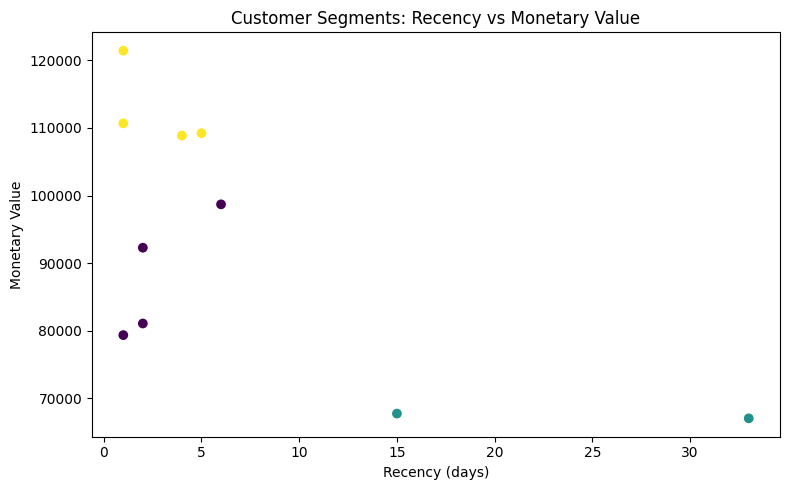

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(rfm["Recency"], rfm["Monetary"], c=rfm["Cluster"])
plt.title("Customer Segments: Recency vs Monetary Value")
plt.xlabel("Recency (days)")
plt.ylabel("Monetary Value")
plt.tight_layout()
plt.show()

## 10. Give simple segment names

In [10]:
# Rank clusters using average monetary value and recency.
# Higher spending + lower recency is treated as a stronger segment.
profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

strongest_cluster = profile["Monetary"].idxmax()
recent_cluster = profile["Recency"].idxmin()

segment_names = {}
for cluster in profile.index:
    if cluster == strongest_cluster and cluster == recent_cluster:
        segment_names[cluster] = "High Value / Recent"
    elif cluster == strongest_cluster:
        segment_names[cluster] = "High Value"
    elif cluster == recent_cluster:
        segment_names[cluster] = "Recent Customers"
    else:
        segment_names[cluster] = "Needs Attention"

rfm["Segment"] = rfm["Cluster"].map(segment_names)

print(rfm[["Customer_Name", "Recency", "Frequency", "Monetary", "Cluster", "Segment"]].sort_values("Cluster").to_string(index=False))

Customer_Name  Recency  Frequency  Monetary  Cluster          Segment
        Ahmed        6         46  98698.70        0 Recent Customers
          Ali        2         46  81082.45        0 Recent Customers
         Chen        2         53  92287.10        0 Recent Customers
          Wei        1         40  79365.30        0 Recent Customers
        Maria       15         41  67761.70        1  Needs Attention
         Riya       33         39  67061.15        1  Needs Attention
         John        1         59 121409.30        2       High Value
         Asha        5         56 109219.65        2       High Value
        Emily        4         63 108870.05        2       High Value
          Sam        1         57 110672.75        2       High Value


## 11. Business recommendations

**High Value / Recent customers**
- Reward them with loyalty offers.
- Recommend related products.
- Try to maintain their engagement.

**Recent Customers**
- Encourage a second purchase.
- Use follow-up offers and product recommendations.

**High Value customers**
- Offer loyalty benefits.
- Monitor whether their purchase frequency remains stable.

**Needs Attention**
- Use targeted discounts or re-engagement campaigns.
- Study why these customers purchase less frequently or spend less.

## 12. Important limitation

The supplied transaction dataset contains only a small number of unique customer names, so this segmentation is suitable as a beginner internship demonstration rather than a production customer-segmentation system. A real company project would normally use a much larger customer dataset with reliable customer IDs and longer purchase history.

## 13. Conclusion

RFM and K-Means turn transaction data into practical customer groups. The main business value is not the cluster number itself, but using the groups to decide how different customers should be approached.